# Eksperimen Machine Learning - Heart Disease Classification
**Nama Peserta:** Dewangga Megananda  
**Dataset:** Heart Disease (UCI Machine Learning Repository)

Notebook ini berisi eksplorasi data (EDA), preprocessing, dan persiapan data untuk modelling.

## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries berhasil diimport!")

Libraries berhasil diimport!


## 2. Load Dataset

In [4]:
# URL file CSV dari GitHub (raw link)
url = "https://raw.githubusercontent.com/nanda910/Eksperimen_SML_Dewangga_Megananda/refs/heads/main/heart_disease_full.csv"

# Load dataset langsung dari GitHub
df = pd.read_csv(url)

print("Dataset berhasil dimuat dari GitHub!")
print(f"Dimensi dataset: {df.shape}")
print("\nInformasi dataset:")
df.info()

Dataset berhasil dimuat dari GitHub!
Dimensi dataset: (297, 14)

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  target    297 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 32.6 KB


In [5]:
# Tampilkan 5 baris pertama
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 3. Exploratory Data Analysis (EDA)

### 3.1 Statistik Deskriptif

In [6]:
# Statistik deskriptif
print("Statistik Deskriptif:")
df.describe()

Statistik Deskriptif:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,0.499340
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


### 3.2 Distribusi Target Variable

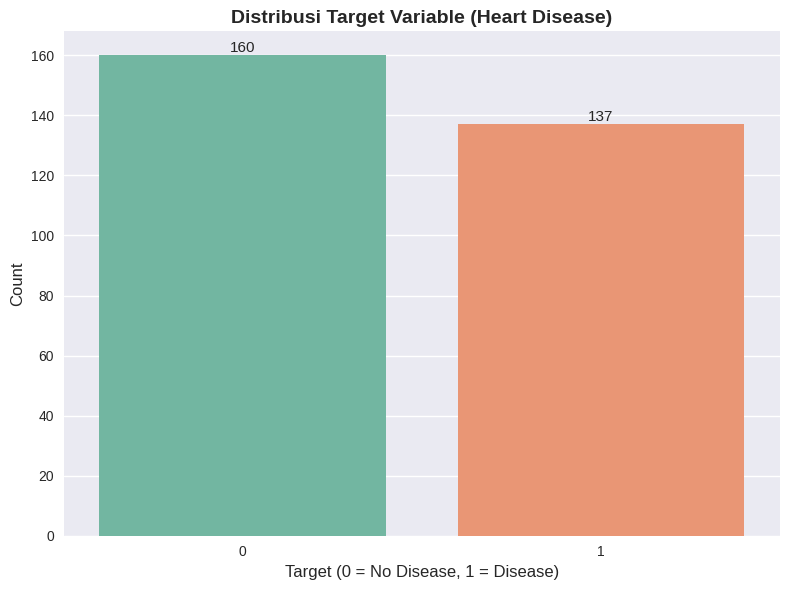


Distribusi Target:
No Disease (0): 160 (53.9%)
Disease (1): 137 (46.1%)


In [7]:
# Visualisasi distribusi target
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='target', palette='Set2')
plt.title('Distribusi Target Variable (Heart Disease)', fontsize=14, fontweight='bold')
plt.xlabel('Target (0 = No Disease, 1 = Disease)', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Tambahkan label pada bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

# Persentase
target_counts = df['target'].value_counts()
print(f"\nDistribusi Target:")
print(f"No Disease (0): {target_counts[0]} ({target_counts[0]/len(df)*100:.1f}%)")
print(f"Disease (1): {target_counts[1]} ({target_counts[1]/len(df)*100:.1f}%)")

### 3.3 Analisis Missing Values

In [8]:
# Cek missing values
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_data,
    'Percentage (%)': missing_percentage
})

print("Missing Values Analysis:")
print(missing_df[missing_df['Missing Values'] > 0])

Missing Values Analysis:
Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []


### 3.4 Analisis Korelasi

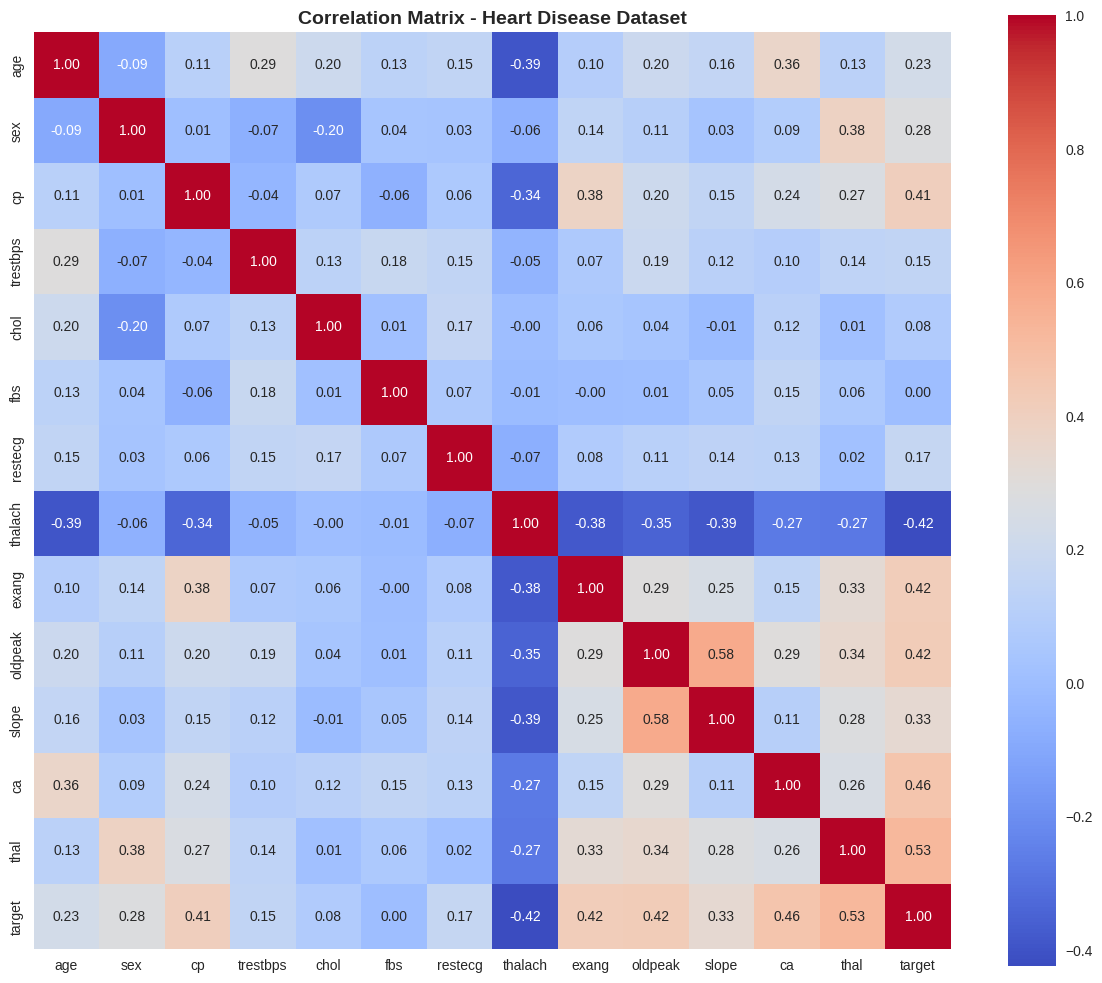

In [9]:
# Korelasi matrix
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Matrix - Heart Disease Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 Distribusi Fitur Numerik

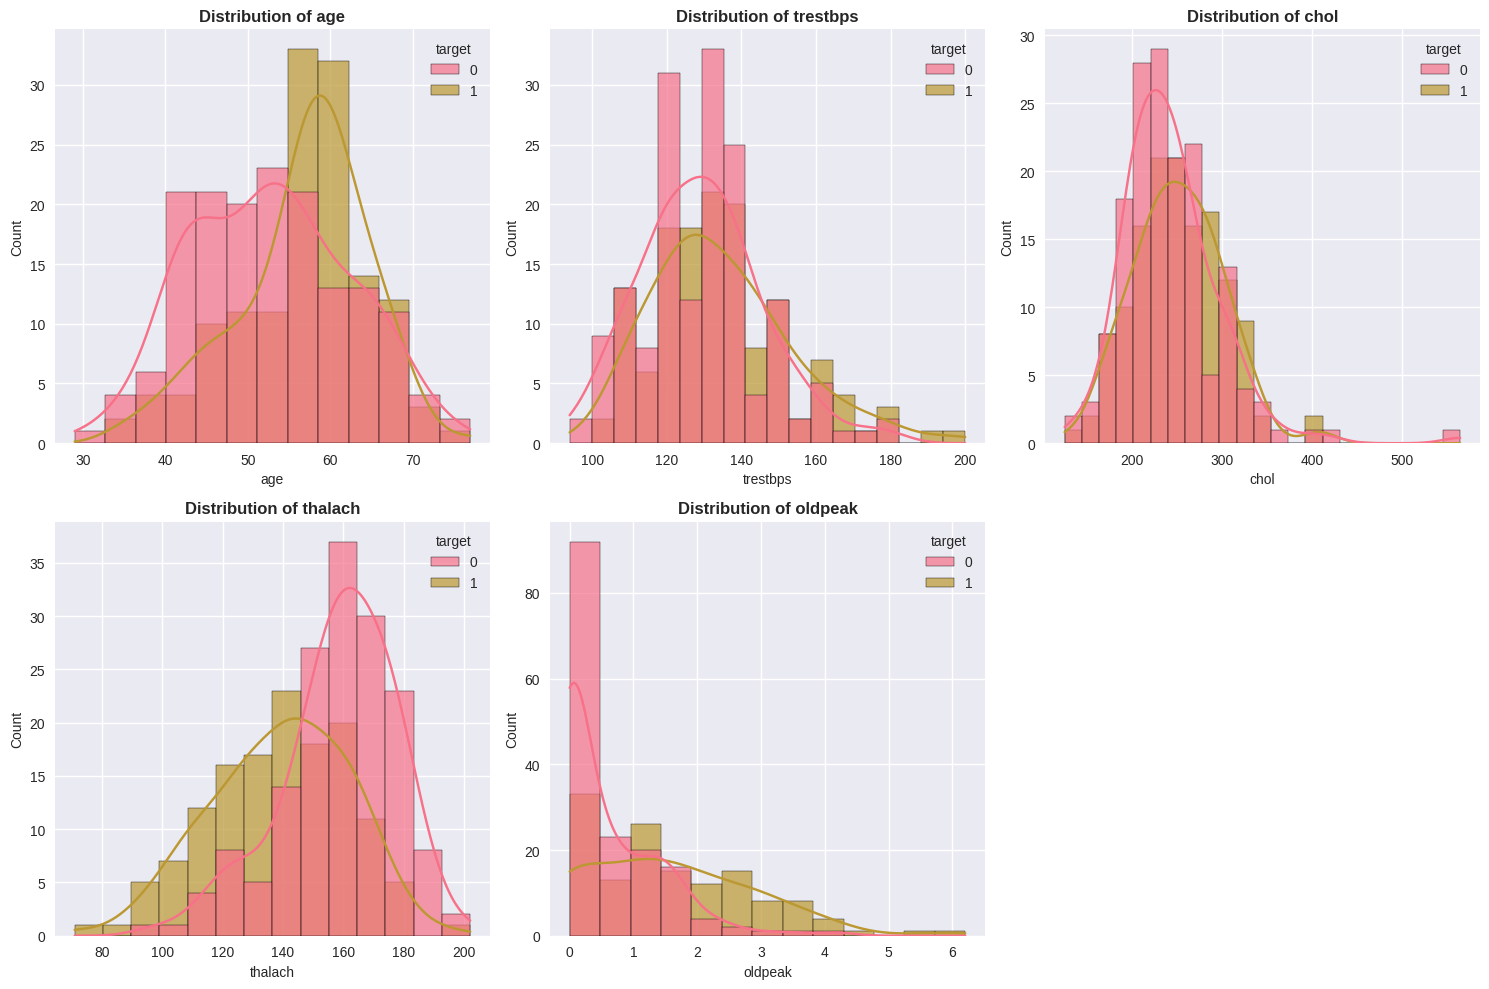

In [10]:
# Fitur numerik
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data=df, x=feature, hue='target', kde=True, alpha=0.7)
    plt.title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    plt.xlabel(feature, fontsize=10)
    plt.ylabel('Count', fontsize=10)

plt.tight_layout()
plt.show()

### 3.6 Analisis Fitur Kategorikal

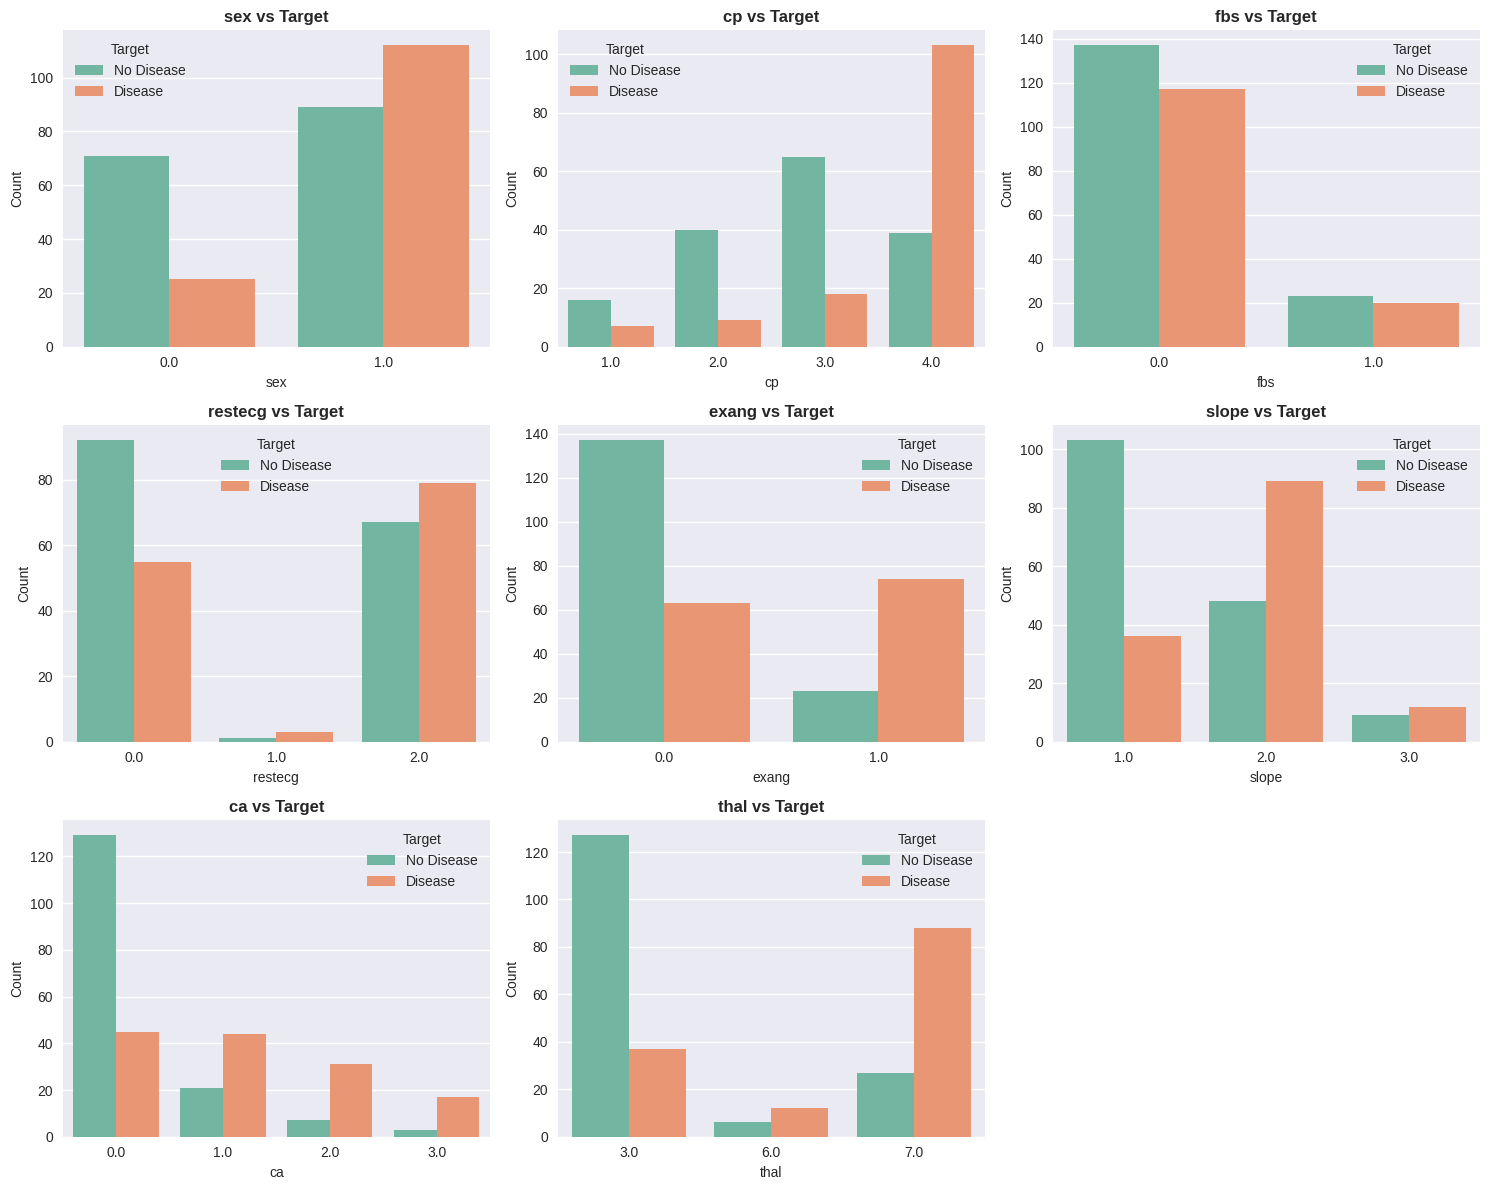

In [11]:
# Fitur kategorikal
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

plt.figure(figsize=(15, 12))
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(3, 3, i)
    sns.countplot(data=df, x=feature, hue='target', palette='Set2')
    plt.title(f'{feature} vs Target', fontsize=12, fontweight='bold')
    plt.xlabel(feature, fontsize=10)
    plt.ylabel('Count', fontsize=10)
    plt.legend(title='Target', labels=['No Disease', 'Disease'])

plt.tight_layout()
plt.show()

## 4. Data Preprocessing

### 4.1 Handle Missing Values

In [12]:
# Cek missing values sebelum preprocessing
print("Missing values sebelum preprocessing:")
print(df.isnull().sum())

# Handle missing values dengan median untuk numerik
numeric_cols = df.select_dtypes(include=[np.number]).columns
imputer = SimpleImputer(strategy='median')
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

print("\nMissing values setelah preprocessing:")
print(df.isnull().sum())

Missing values sebelum preprocessing:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Missing values setelah preprocessing:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


### 4.2 Encoding Categorical Variables

In [13]:
# Categorical features yang perlu di-encode
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Label encoding untuk ordinal features
label_encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col].astype(str))

print("Categorical encoding selesai!")
print(f"\nDimensi dataset setelah encoding: {df.shape}")

Categorical encoding selesai!

Dimensi dataset setelah encoding: (297, 14)


### 4.3 Feature Scaling

In [14]:
# Features yang perlu di-scale (semua kecuali target)
features_to_scale = [col for col in df.columns if col != 'target']

# Standard scaling
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("Feature scaling selesai!")
print("\nStatistik setelah scaling:")
df_scaled[features_to_scale].describe()

Feature scaling selesai!

Statistik setelah scaling:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,2.970000e+02,2.970000e+02,2.970000e+02,2.970000e+02,2.970000e+02,2.970000e+02,2.970000e+02,2.970000e+02,2.970000e+02,297.000000,2.970000e+02,2.970000e+02,2.970000e+02
mean,-1.226105e-16,-7.177199e-17,-4.037175e-17,4.904420e-16,-1.958777e-16,-4.186700e-17,4.784800e-17,4.784800e-16,-3.289550e-17,0.000000,-1.136390e-16,-7.775299e-17,3.588600e-17
std,1.001688e+00,1.001688e+00,1.001688e+00,1.001688e+00,1.001688e+00,1.001688e+00,1.001688e+00,1.001688e+00,1.001688e+00,1.001688,1.001688e+00,1.001688e+00,1.001688e+00
min,-2.827176e+00,-1.446980e+00,-2.240629e+00,-2.125634e+00,-2.337704e+00,-4.114503e-01,-1.003419e+00,-3.431849e+00,-6.964194e-01,-0.906712,-9.765832e-01,-7.219761e-01,-8.742915e-01
25%,-7.241238e-01,-1.446980e+00,-1.642895e-01,-6.594306e-01,-7.002541e-01,-4.114503e-01,-1.003419e+00,-7.247694e-01,-6.964194e-01,-0.906712,-9.765832e-01,-7.219761e-01,-8.742915e-01
50%,1.613719e-01,6.910947e-01,-1.642895e-01,-9.550637e-02,-8.380217e-02,-4.114503e-01,3.389928e-03,1.484822e-01,-6.964194e-01,-0.219520,6.437811e-01,-7.219761e-01,-8.742915e-01
75%,7.148067e-01,6.910947e-01,8.738802e-01,4.684179e-01,5.519138e-01,-4.114503e-01,1.010199e+00,7.160957e-01,1.435916e+00,0.467672,6.437811e-01,3.448244e-01,1.219778e+00
max,2.485798e+00,6.910947e-01,8.738802e-01,3.851964e+00,6.099981e+00,2.430427e+00,1.010199e+00,2.287949e+00,1.435916e+00,4.419026,2.264145e+00,2.478425e+00,1.219778e+00


### 4.4 Train/Test Split

In [15]:
# Split features dan target
X = df_scaled.drop('target', axis=1)
y = df_scaled['target']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train/Test split selesai!")
print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nDistribusi target di train set:")
print(y_train.value_counts())
print(f"\nDistribusi target di test set:")
print(y_test.value_counts())

Train/Test split selesai!
Train set: 237 samples
Test set: 60 samples

Distribusi target di train set:
target
0.0    128
1.0    109
Name: count, dtype: int64

Distribusi target di test set:
target
0.0    32
1.0    28
Name: count, dtype: int64


### 4.5 Simpan Preprocessed Data

In [17]:
# Gabungkan X_train dan y_train untuk disimpan
train_processed = X_train.copy()
train_processed['target'] = y_train

# Gabungkan X_test dan y_test untuk disimpan
test_processed = X_test.copy()
test_processed['target'] = y_test

# Create the directory if it doesn't exist
import os
os.makedirs('dataset_preprocessing', exist_ok=True)

# Simpan ke CSV
train_processed.to_csv('dataset_preprocessing/train_processed.csv', index=False)
test_processed.to_csv('dataset_preprocessing/test_processed.csv', index=False)

print("Preprocessed data berhasil disimpan!")
print("Files:")
print("- dataset_preprocessing/train_processed.csv")
print("- dataset_preprocessing/test_processed.csv")
print("- Eksperimen_SML_Dewangga_Megananda.txt (https://github.com/nanda910/SMSL_Dewangga_Megananda)")

Preprocessed data berhasil disimpan!
Files:
- dataset_preprocessing/train_processed.csv
- dataset_preprocessing/test_processed.csv
- Eksperimen_SML_Dewangga_Megananda.txt (https://github.com/nanda910/SMSL_Dewangga_Megananda)


## 5. Summary

In [18]:
print("=== EKSERIMEN PREPROCESSING SUMMARY ===")
print(f"Dataset: Heart Disease Classification")
print(f"Total samples: {len(df)}")
print(f"Features: {len(df.columns)-1}")
print(f"Target classes: {df['target'].nunique()}")
print()
print("Preprocessing steps completed:")
print("✓ Missing value handling")
print("✓ Categorical encoding")
print("✓ Feature scaling")
print("✓ Train/test split")
print("✓ Data export")
print()
print("Files generated:")
print("- train_processed.csv")
print("- test_processed.csv")
print("- Eksperimen_SML_Dewangga_Megananda.txt (https://github.com/nanda910/SMSL_Dewangga_Megananda)")

=== EKSERIMEN PREPROCESSING SUMMARY ===
Dataset: Heart Disease Classification
Total samples: 297
Features: 13
Target classes: 2

Preprocessing steps completed:
✓ Missing value handling
✓ Categorical encoding
✓ Feature scaling
✓ Train/test split
✓ Data export

Files generated:
- train_processed.csv
- test_processed.csv
- Eksperimen_SML_Dewangga_Megananda.txt (https://github.com/nanda910/SMSL_Dewangga_Megananda)
